## Initialization

In [1]:
import math

import numpy as np

import pandas as pd

import torch
import transformers

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

## Data Loading

In [4]:
df_reviews = pd.read_csv("../data/imdb_reviews.tsv", sep='\t')

In [5]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  str    
 1   title_type       47331 non-null  str    
 2   primary_title    47331 non-null  str    
 3   original_title   47331 non-null  str    
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  str    
 6   runtime_minutes  47331 non-null  str    
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  str    
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  float64
 11  review           47331 non-null  str    
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  str    
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  str    
 16  idx              47331 non-null  int64  
dtypes: float64(2), int64(5)

## Data Preprocessing

In [6]:
# Removing NaN values from the dataset. Since the analysis showed only 2 rows contain missing values out of 47330 rows

reviews_clean = df_reviews.dropna()


In [7]:
# Verifying duplicated values

print(reviews_clean.duplicated().sum())


0


In [8]:
# Selecting columns to remove 

cols_model_extended = set(['review', 'pos', 'genres', 'average_rating', 'votes'])
columns_original = set(df_reviews.columns)
columns_removed = columns_original - cols_model_extended

print(columns_removed)


{'idx', 'primary_title', 'end_year', 'runtime_minutes', 'original_title', 'ds_part', 'start_year', 'rating', 'sp', 'is_adult', 'tconst', 'title_type'}


In [9]:
# Removing columns with low predictive value for sentiment analysis
# Keeping: review, pos, genres, average_rating, votes (features relevant to classification)

reviews_clean = reviews_clean.drop(columns=list(columns_removed))


Only variables directly related to the review text were retained, in order to evaluate the intrinsic predictive power of linguistic information. Identifier columns, redundant variables, and contextual metadata were excluded to prevent data leakage, reduce noise, and maintain model interpretability.

### Verifying the quality of the reviews

In [10]:
# Verifying if there are empty reviews

empty_reviews = reviews_clean[reviews_clean['review'].str.strip() == '']
print("Empty reviews:", len(empty_reviews))


Empty reviews: 0


In [11]:
# Identifying duplicated reviews

reviews_clean['review'].duplicated().sum()


np.int64(91)

In [12]:
# Removing duplicated reviews

reviews_clean = reviews_clean.drop_duplicates(subset='review')

print(reviews_clean['review'].duplicated().sum())


0


In [13]:
# Analysing review length

reviews_lenght = reviews_clean['review'].str.len()
reviews_lenght.describe()


count    47238.000000
mean      1290.753228
std        975.472777
min         32.000000
25%        691.000000
50%        958.000000
75%       1567.000000
max      13594.000000
Name: review, dtype: float64

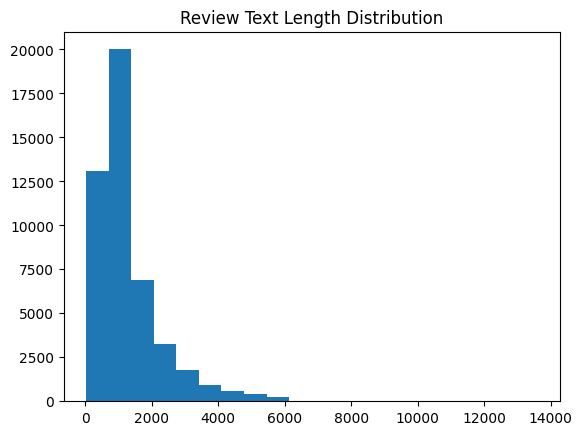

In [14]:
# Analyzing the distribution of reviews text length

plt.hist(reviews_lenght, bins=20)
plt.title('Review Text Length Distribution')
plt.show()


In [15]:
# Detecting URL and HTML tag contamination in review text

print(reviews_clean['review'].str.contains('http').sum())
print(reviews_clean['review'].str.contains('<.*?>').sum())


111
12


In [16]:
# Removing URLs and HTML tags using regex pattern matching

reviews_clean['review'] = reviews_clean['review'].str.replace(r'http\S+|<.*?>', '', regex=True)

reviews_clean.shape


(47238, 5)

In [17]:
# Confirming successful removal of URLs and HTML artifacts

print(reviews_clean['review'].str.contains('http').sum())
print(reviews_clean['review'].str.contains('<.*?>').sum())


0
0


In [18]:

df_model = reviews_clean[['review', 'pos']]

df_model_extended = reviews_clean.copy()

df_reviews = df_reviews.drop(columns=['idx', 'sp'])


Three datasets have been designed for different purposes within the project.

The first dataset, df_model, includes only the review and pos variables, where pos is the target variable. This dataset will be used to train the baseline model, establishing a clear reference point before incorporating additional variables or more complex optimizations.

The second dataset, df_model_extended, contains all variables that, beyond the review text, were considered to have predictive potential. This dataset will be used to evaluate whether incorporating structured information (such as movie-level features) improves model performance over the baseline.

Finally, the third dataset, df_reviews, retains most of the original columns and is intended exclusively for exploratory data analysis (EDA). This allows patterns, distributions, and potential relationships between variables to be analyzed without directly affecting the modeling pipeline.


## EDA

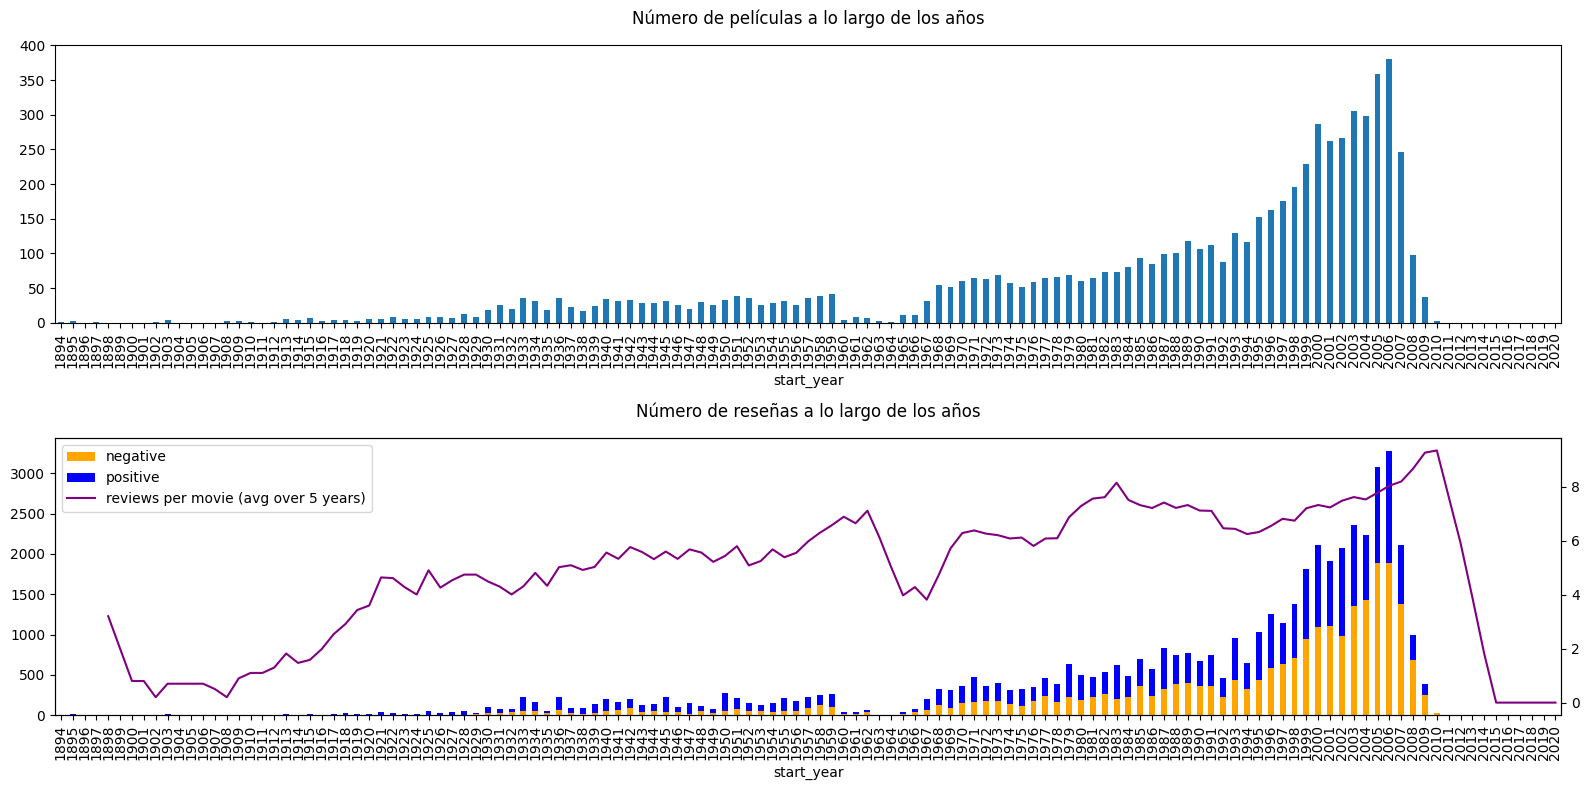

In [26]:
# Number of movies and reviews over the years

fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(range(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años', pad=15)

ax2 = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(range(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft2.columns = ['negative', 'positive']

dft2.plot(kind='bar', stacked=True, color=['orange', 'blue'], label='#reviews (neg, pos)', ax=ax2)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(range(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax2.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='purple', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines2 + lines, labels2 + labels, loc='upper left')

ax2.set_title('Número de reseñas a lo largo de los años', pad=15)

fig.tight_layout()


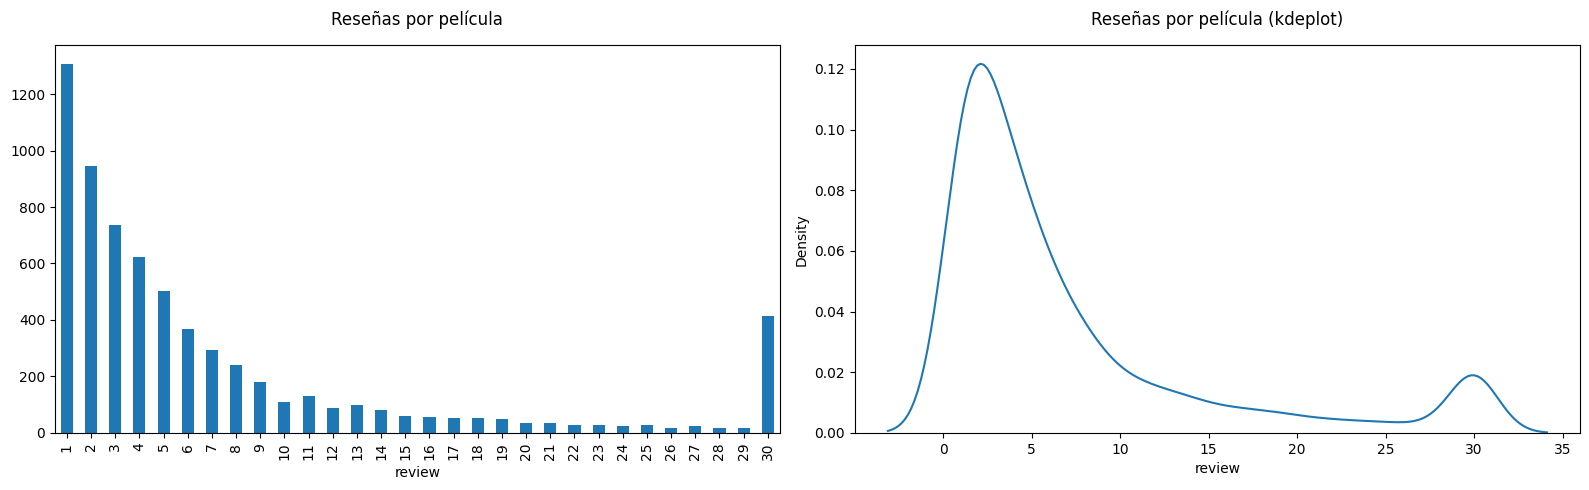

In [25]:
# Distribution and KDE plot of reviews per movie

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Reseñas por película', pad=15)


ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Reseñas por película (kdeplot)', pad=15)

fig.tight_layout()

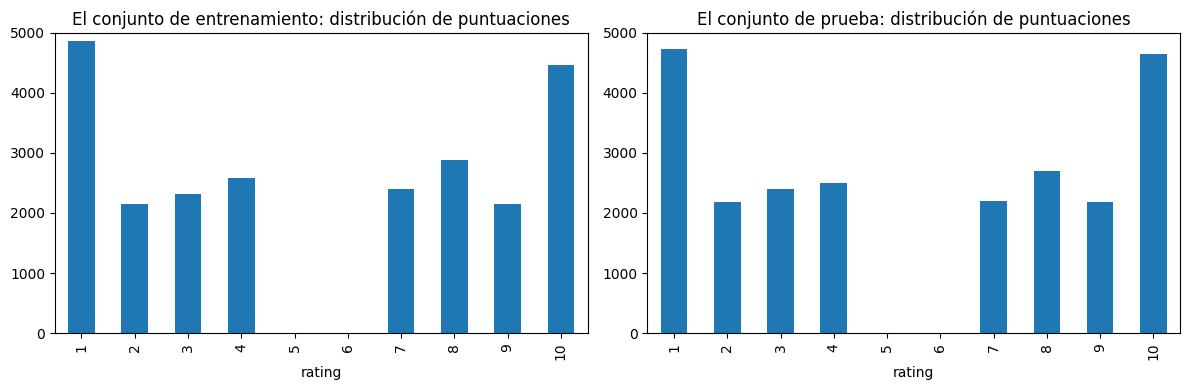

In [24]:
# Distribution of ratings in train and test sets

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('El conjunto de prueba: distribución de puntuaciones')

fig.tight_layout()

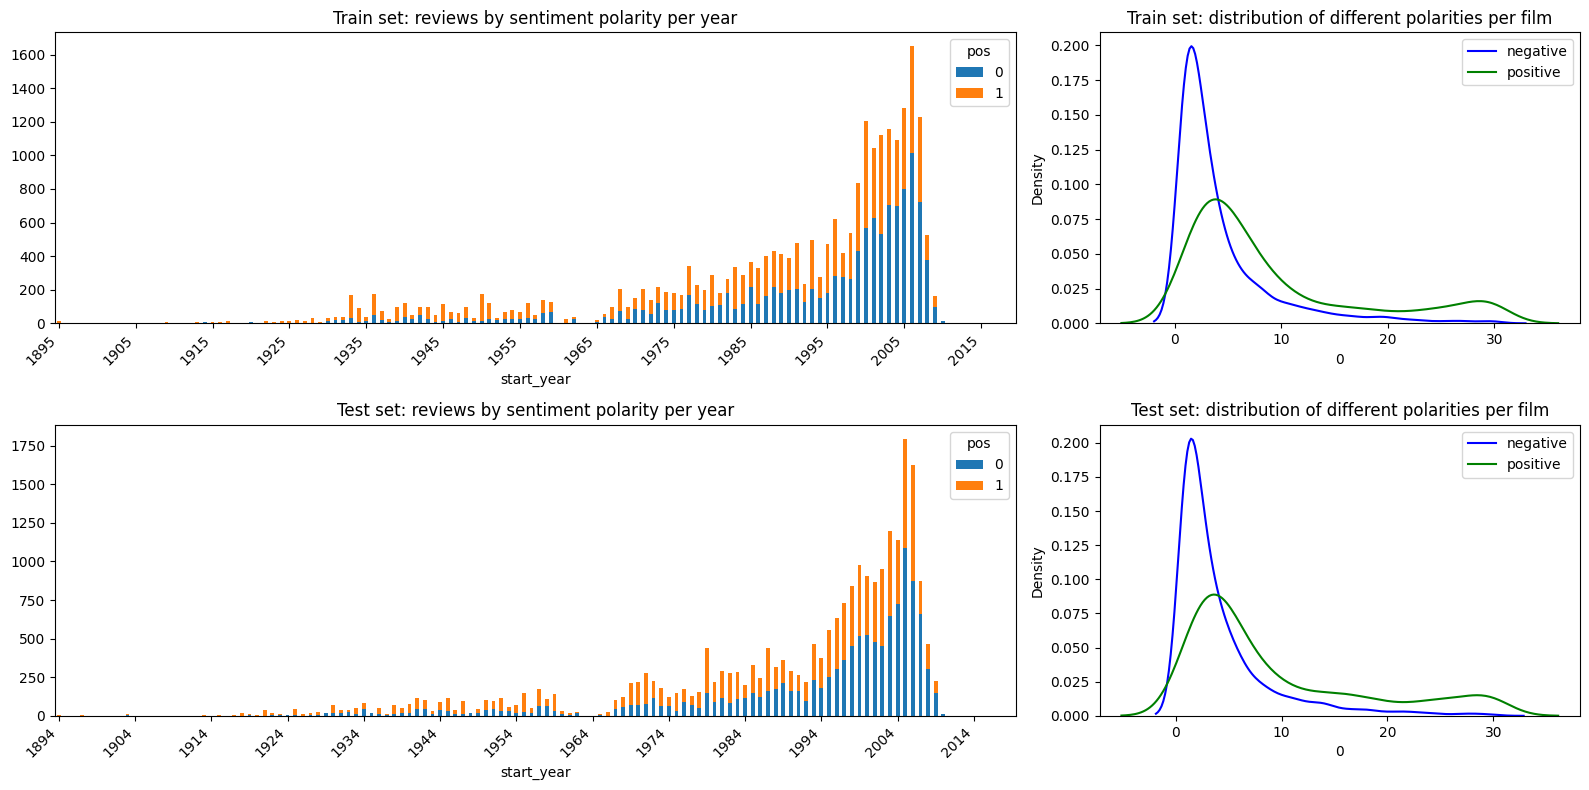

In [32]:
# Sentiment Distribution by Year and by Film (Train vs. Test)

fig, axs = plt.subplots(2, 2, figsize=(
    16, 8), gridspec_kw=dict(width_ratios=(2, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(
    ['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(
    dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
tick_positions = range(0, len(dft), 10)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([str(dft.index[i])
                   for i in tick_positions], rotation=45, ha='right')
ax.set_title('Train set: reviews by sentiment polarity per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(
    ['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('Train set: distribution of different polarities per film')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(
    ['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(
    dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
tick_positions = range(0, len(dft), 10)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels([str(dft.index[i])
                   for i in tick_positions], rotation=45, ha='right')
ax.set_title('Test set: reviews by sentiment polarity per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(
    ['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('Test set: distribution of different polarities per film')

fig.tight_layout()

## Comprehensive Model Evaluation and Threshold Analysis

In [35]:
import sklearn.metrics as metrics


def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for subset, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[subset] = {}

        pred_target = model.predict(features)
        
        # For LinearSVC, which does not have predict_proba, we can use decision_function to get the scores
        
        if hasattr(model, "predict_proba"):
            pred_proba = model.predict_proba(features)[:, 1]
        else:
            pred_proba = model.decision_function(features)
        
        # F1

        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC

        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[subset]['ROC AUC'] = roc_auc

        # PRC 
        
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[subset]['APS'] = aps

        if subset == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{subset}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Value')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{subset}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'ROC Curve')

        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{subset}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'Precision-Recall Curve')

        eval_stats[subset]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[subset]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return


## Dataset Partitioning Using a Predefined Train–Test Split

In [36]:

df_reviews_train = df_model[df_reviews.loc[df_model.index, 'ds_part'] == 'train']
df_reviews_test = df_model[df_reviews.loc[df_model.index, 'ds_part'] == 'test']


train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']


print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23757, 2)
(23481, 2)


## Text Preprocessing: Basic Cleaning and Lemmatization

In [ ]:

import re

corpus_train = df_reviews_train['review']
corpus_test = df_reviews_test['review']

def corpus_cleaned (corpus, desc="Processing"):
    
    cleaned_texts = []
    
    for review in tqdm(corpus, desc=desc):
        review = " ".join(re.sub(r"[^a-zA-Z']", " ", review).split()).lower()
        cleaned_texts.append(review)

    return cleaned_texts

train_clean = corpus_cleaned(corpus_train, "Train preprocessing")
test_clean = corpus_cleaned(corpus_test, "Test preprocessing")

np.save("train_cleaned.npy", train_clean)
np.save("test_cleaned.npy", test_clean)


In [ ]:
import spacy


nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def process_corpus(corpus, desc="Processing"):
    
    cleaned_texts = (
        " ".join(re.sub(r"[^a-zA-Z']", " ", review).split()).lower()
        for review in corpus
    )
    
    processed = []
    
    for doc in tqdm(nlp.pipe(cleaned_texts, batch_size=500),
                    desc=desc,
                    total=len(corpus)):
        
        lemmas = [token.lemma_ for token in doc]
        processed.append(" ".join(lemmas))
        
    return processed


train_lemmatized = process_corpus(corpus_train, "Train preprocessing")
test_lemmatized = process_corpus(corpus_test, "Test preprocessing")

np.save("train_lemmatized.npy", train_lemmatized)
np.save("test_lemmatized.npy", test_lemmatized)


In [ ]:
# Normal version of BERT tokenizer

from transformers import AutoTokenizer, AutoModel
from transformers import logging


logging.set_verbosity_error()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased").to(device)
model.eval()

def get_embeddings(texts, batch_size=32, desc="Processing"):

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=desc):

        batch_texts = texts[i:i+batch_size]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()


train_embeddings = get_embeddings(corpus_train.tolist(), desc="Train")
test_embeddings = get_embeddings(corpus_test.tolist(), desc="Test")


np.save("train_embeddings.npy", train_embeddings)  
np.save("test_embeddings.npy", test_embeddings)


In [ ]:
train_clean = np.load(r"..\data\train_cleaned.npy", allow_pickle=True)
test_clean = np.load(r"..\data\test_cleaned.npy", allow_pickle=True)

train_lemmatized = np.load(r"..\data\train_lemmatized.npy", allow_pickle=True)
test_lemmatized = np.load(r"..\data\test_lemmatized.npy", allow_pickle=True)

train_embeddings = np.load(r"..\data\train_embeddings.npy", allow_pickle=True)
test_embeddings = np.load(r"..\data\test_embeddings.npy", allow_pickle=True)

print(train_clean.shape, test_clean.shape)
print(train_lemmatized.shape, test_lemmatized.shape)
print(train_embeddings.shape, test_embeddings.shape)

(23757,) (23481,)
(23757,) (23481,)
(23757, 768) (23481, 768)


## Model Development and Evaluation

In [ ]:
# splitting data into features and target for both cleaned and lemmatized versions using the dataset "df_model"

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf_basic = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_basic = tfidf_basic.fit_transform(train_clean)
X_test_basic = tfidf_basic.transform(test_clean)


tfidf_lemm = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9
)

X_train_lemm = tfidf_lemm.fit_transform(train_lemmatized)
X_test_lemm = tfidf_lemm.transform(test_lemmatized)


y_train = train_target
y_test = test_target

print(X_train_basic.shape, X_test_basic.shape)
print(X_train_lemm.shape, X_test_lemm.shape)


(23757, 148673) (23481, 148673)
(23757, 135413) (23481, 135413)


### Baseline Text-Based Modeling and Hyperparameter Optimization

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV, ParameterGrid

best_params = {}

def train_eval_with_search(model, param_grid,
                           X_train, X_test,
                           y_train, y_test,
                           model_name="Model"):

    print(f"\n===== {model_name} =====")

    if not param_grid:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        print(f"\nBest {model_name} F1 Score: {metrics.f1_score(y_test, preds):.2f} \n")
        print("Best params: {}")
        evaluate_model(model, X_train, y_train, X_test, y_test)
        return

    total_params = len(ParameterGrid(param_grid))
    actual_iter = min(10, total_params)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=actual_iter,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    
    print(f"\nBest {model_name} F1 Score: {metrics.f1_score(y_test, preds):.2f} \n")

    print("Best params:", search.best_params_)
    best_params[model_name] = search.best_params_

    evaluate_model(best_model, X_train, y_train, X_test, y_test)
    

The train_eval_with_search function handles model training and hyperparameter optimization using RandomizedSearchCV (except for the Dummy classifier, which requires no tuning). For each model, the function performs a parameter search via cross-validation to identify the best hyperparameter configuration based on the F1 metric.
Once the optimal parameters are selected, the best estimator is evaluated on the test set. Performance is assessed using the F1 metric and further analyzed through the evaluate_model function, which provides visual diagnostics including:

1. F1 scores across different classification thresholds.
2. Receiver Operating Characteristic (ROC) curve.
3. Precision-Recall Curve (PRC).

This approach ensures a consistent and fair comparison across models, offering both quantitative metrics and graphical insight into classification performance.

In [40]:
# Relevant parameters for tuning each model

dummy_params = {}

nb_params = {
    "alpha": [0.1, 0.5, 1.0]
}

logreg_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

svm_params = {
    "C": [0.01, 0.1, 1, 10]
}



===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== MultinomialNB =====

Best MultinomialNB F1 Score: 0.87 

Best params: {'alpha': 0.5}
          train  test
Accuracy   0.94  0.87
F1         0.94  0.87
APS        0.99  0.94
ROC AUC    0.99  0.94

===== LogReg =====

Best LogReg F1 Score: 0.90 

Best params: {'solver': 'liblinear', 'C': 10}
          train  test
Accuracy    1.0  0.90
F1          1.0  0.90
APS         1.0  0.96
ROC AUC     1.0  0.96

===== SVM =====

Best SVM F1 Score: 0.90 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.90
F1          1.0  0.90
APS         1.0  0.96
ROC AUC     1.0  0.96


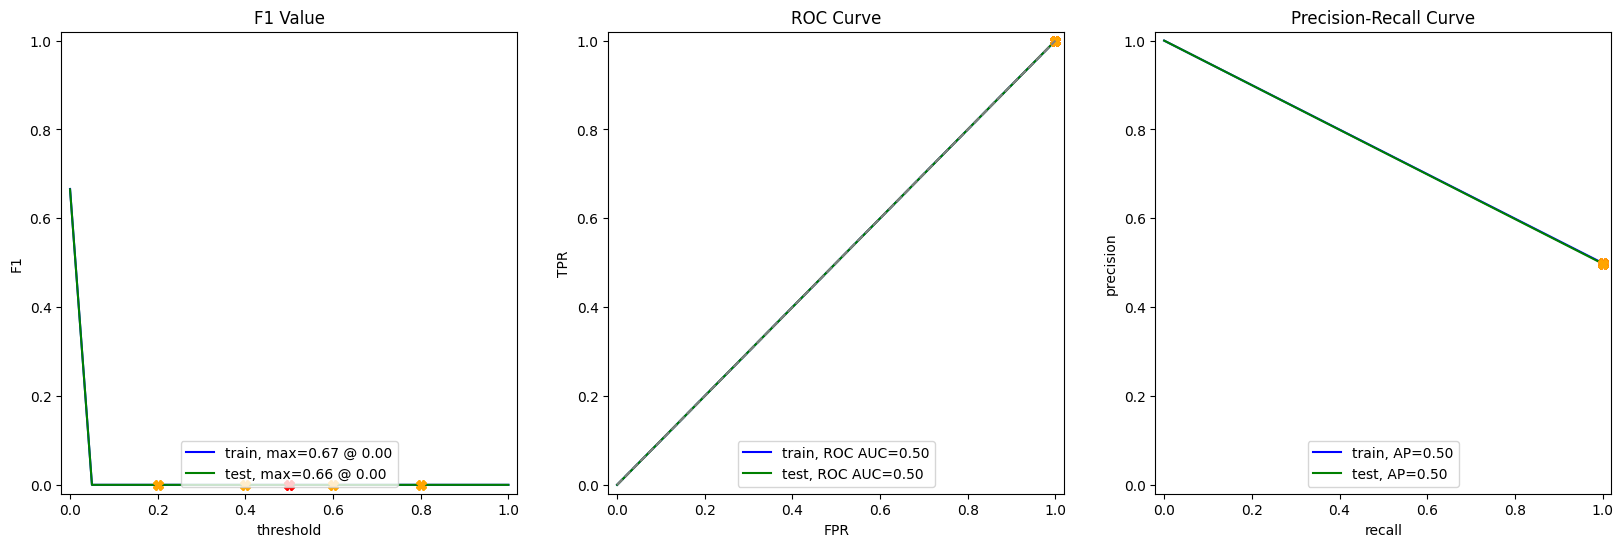

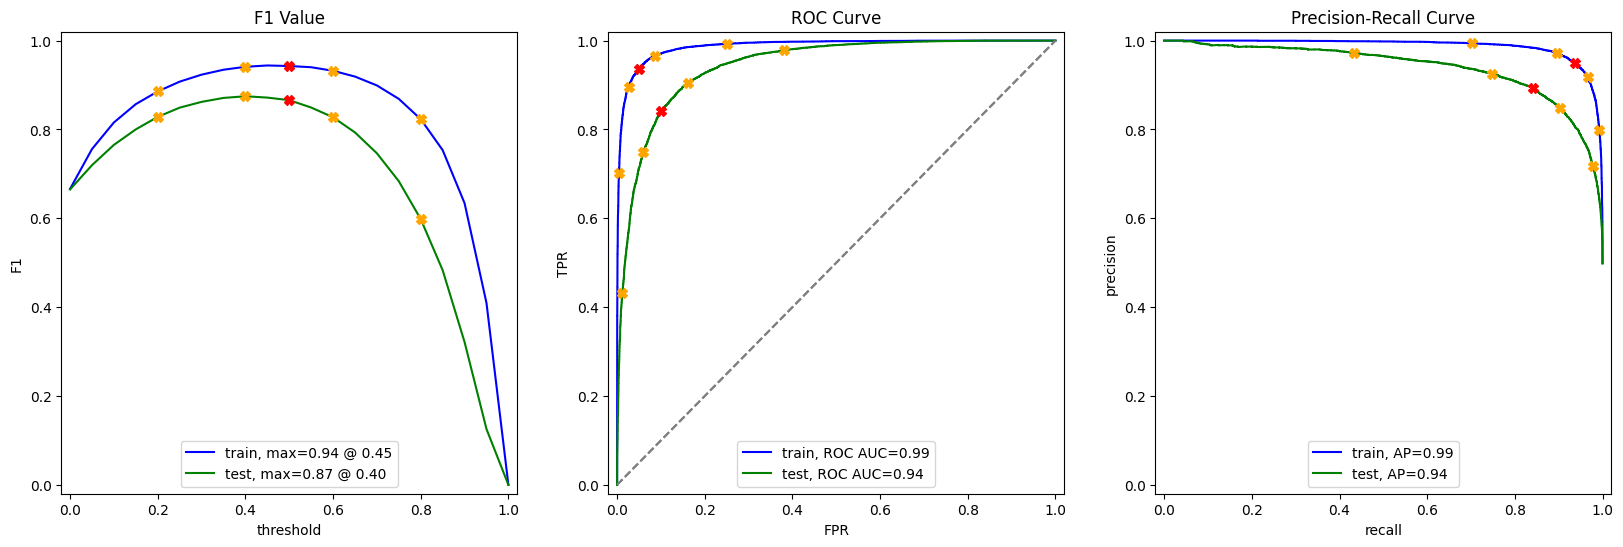

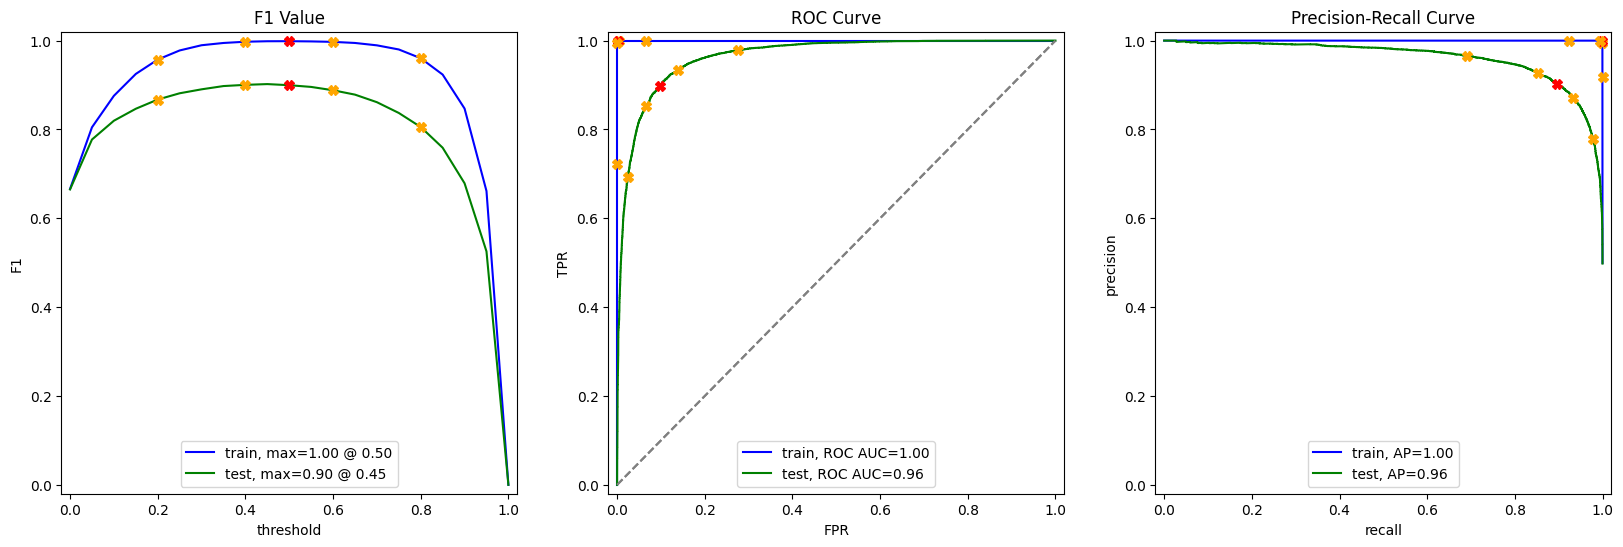

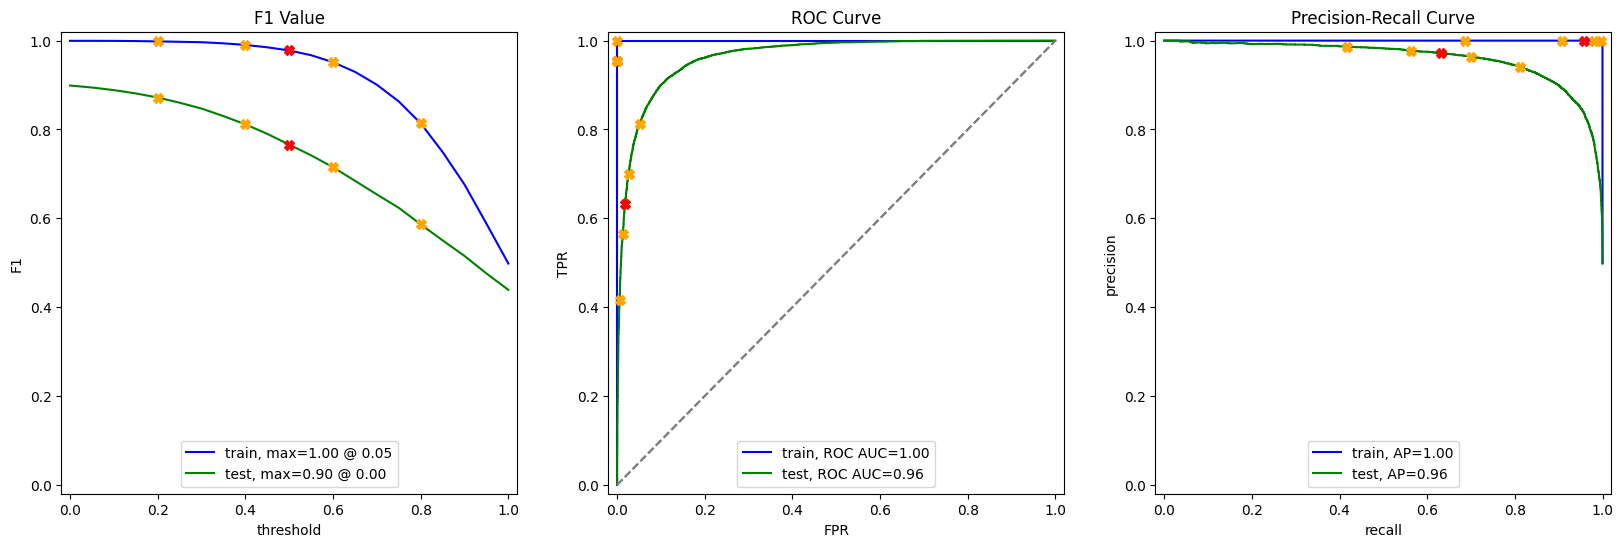

In [ ]:
# Model Evaluation on Cleaned Text (Unigrams and Bigrams, No Lemmatization)

models = [
    ("Dummy", DummyClassifier(strategy="most_frequent"), dummy_params),
    ("MultinomialNB", MultinomialNB(), nb_params),
    ("LogReg", LogisticRegression(max_iter=1000), logreg_params),
    ("SVM", LinearSVC(), svm_params)
]

for name, model, params in models:
    train_eval_with_search(
        model,
        params,
        X_train_basic,
        X_test_basic,
        y_train,
        y_test,
        model_name=name
    )
    


===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== MultinomialNB =====

Best MultinomialNB F1 Score: 0.86 

Best params: {'alpha': 0.5}
          train  test
Accuracy   0.94  0.86
F1         0.94  0.86
APS        0.99  0.94
ROC AUC    0.99  0.94

===== LogReg =====

Best LogReg F1 Score: 0.90 

Best params: {'solver': 'liblinear', 'C': 10}
          train  test
Accuracy    1.0  0.90
F1          1.0  0.90
APS         1.0  0.96
ROC AUC     1.0  0.96

===== SVM =====

Best SVM F1 Score: 0.90 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.90
F1          1.0  0.90
APS         1.0  0.96
ROC AUC     1.0  0.96


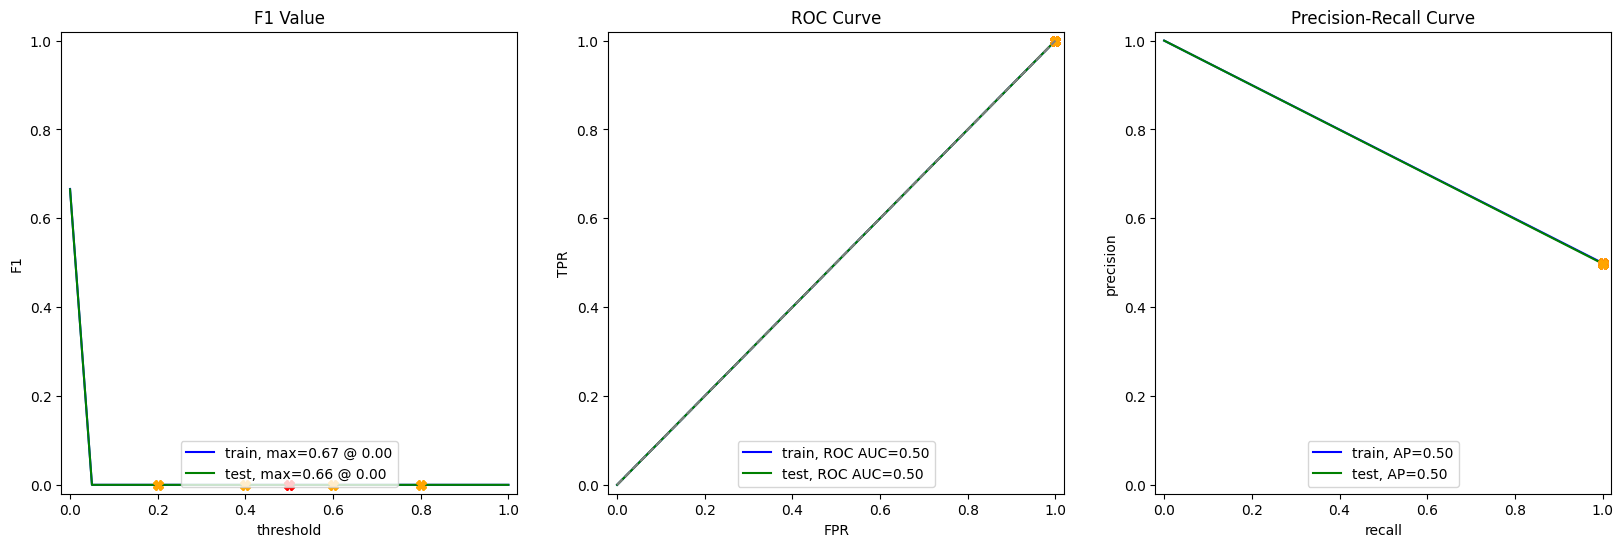

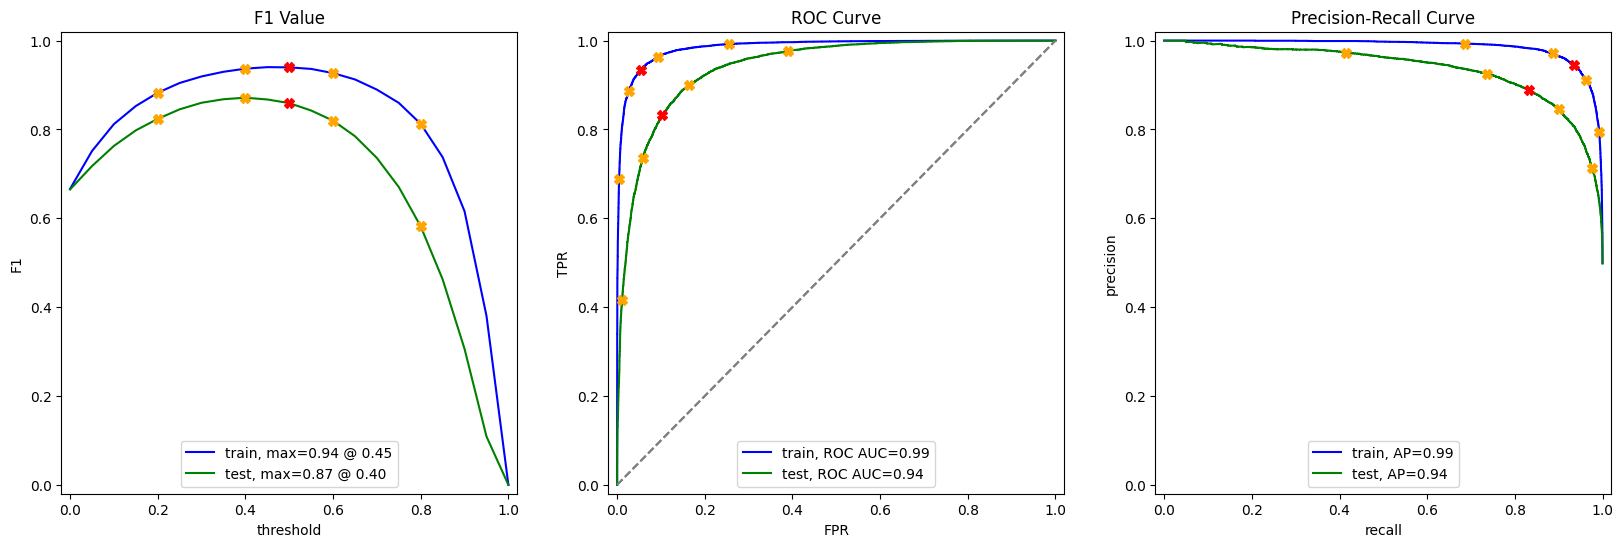

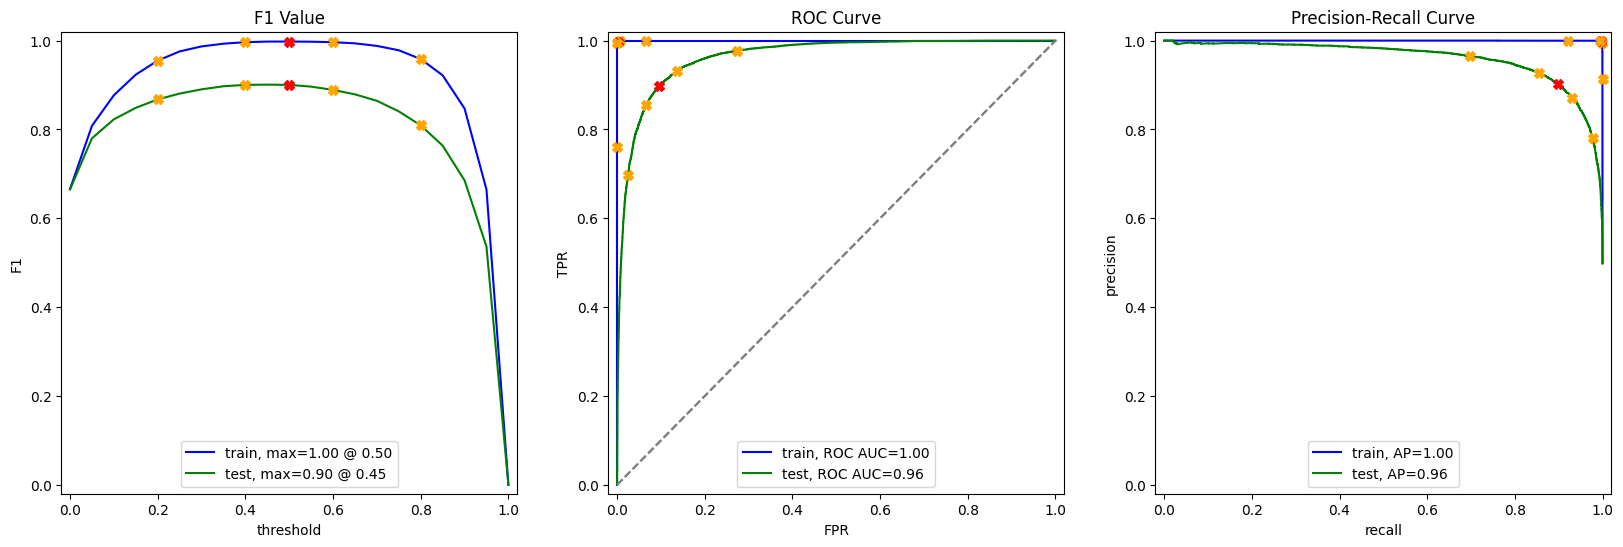

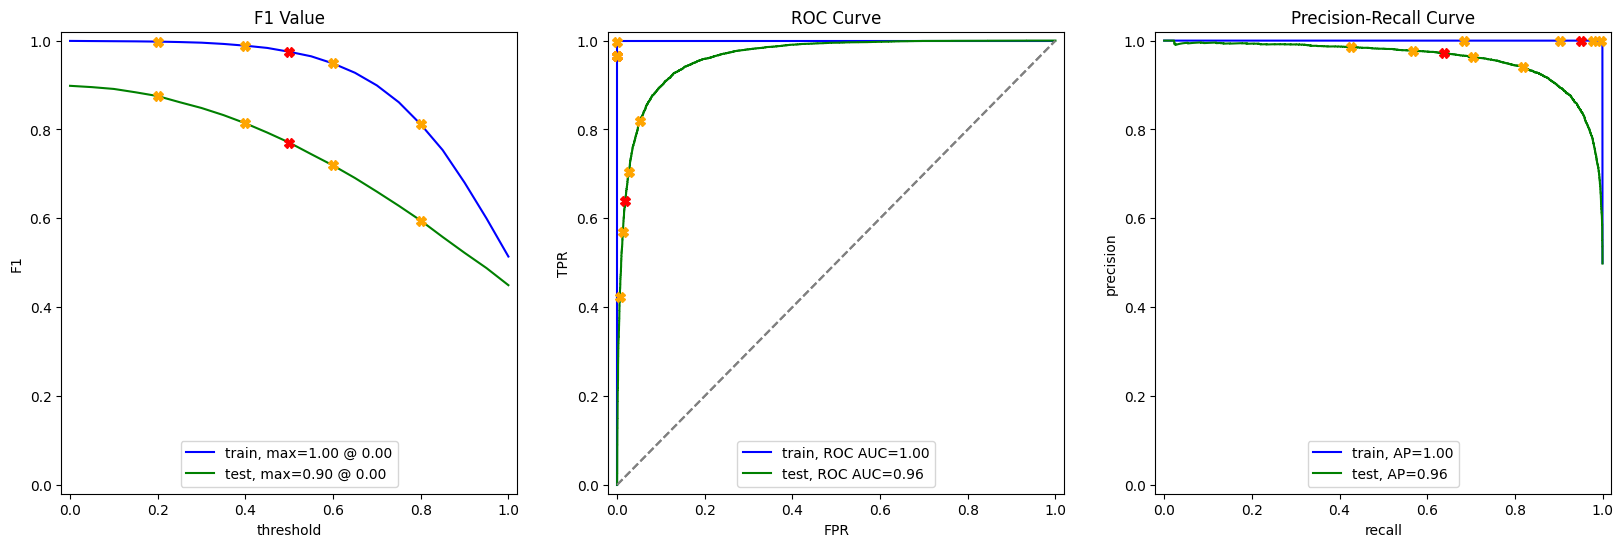

In [42]:
# Model Evaluation on Lemmatized Text as well as unigrams and bigrams

for name, model, params in models:
    train_eval_with_search(
        model,
        params,
        X_train_lemm,
        X_test_lemm,    
        y_train,
        y_test,
        model_name=name
    )
    

### Feature-Enriched Modeling and Hyperparameter Optimization

In [43]:
# splitting data into features and target for both cleaned and lemmatized versions using the dataset "df_model_extended"

df_extended_train_basic = df_model_extended[df_reviews.loc[df_model_extended.index, 'ds_part'] == 'train']
df_extended_test_basic = df_model_extended[df_reviews.loc[df_model_extended.index, 'ds_part'] == 'test']

y_train = df_extended_train_basic['pos']
y_test = df_extended_test_basic['pos']

print(df_extended_train_basic.shape)
print(df_extended_test_basic.shape)


(23757, 5)
(23481, 5)


In [48]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer

# Genres
genre_vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split(','),
    token_pattern=None,
    binary=True
)

X_train_genres_basic = genre_vectorizer.fit_transform(df_extended_train_basic['genres'])
X_test_genres_basic = genre_vectorizer.transform(df_extended_test_basic['genres'])

# Numeric
scaler = StandardScaler()
X_train_num = scaler.fit_transform(df_extended_train_basic[['average_rating', 'votes']])
X_test_num = scaler.transform(df_extended_test_basic[['average_rating', 'votes']])

X_train_num_sparse_basic = csr_matrix(X_train_num)
X_test_num_sparse_basic = csr_matrix(X_test_num)

# Combine basic tokenized features with genres and numeric features
X_extend_train_basic = hstack([X_train_basic, X_train_genres_basic, X_train_num_sparse_basic])
X_extend_test_basic = hstack([X_test_basic, X_test_genres_basic, X_test_num_sparse_basic])

# Combine lemmatized and tokenized reviews with genres and numeric features
X_extend_train_lemm = hstack([X_train_lemm, X_train_genres_basic, X_train_num_sparse_basic])
X_extend_test_lemm = hstack([X_test_lemm, X_test_genres_basic, X_test_num_sparse_basic])


print(X_extend_train_basic.shape, X_extend_test_basic.shape)
print(X_extend_train_lemm.shape, X_extend_test_lemm.shape)


(23757, 148704) (23481, 148704)
(23757, 135444) (23481, 135444)


To enrich the model, additional structured variables were incorporated into the text representation. The genres variable was transformed using CountVectorizer with binary=True, generating a binary encoding where each genre is represented as an independent feature.

The numeric variables (average_rating and votes) were standardized using StandardScaler to ensure comparable scales across features.

Finally, the text representations, both in their basic and lemmatized versions, were combined via horizontal concatenation with the genre and scaled numeric variables, producing an extended feature matrix. Note that the structured variables are identical in both versions; only the text preprocessing differs between them.


===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== LogReg =====

Best LogReg F1 Score: 0.91 

Best params: {'solver': 'liblinear', 'C': 10}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97

===== SVM =====


c:\Users\ariex\anaconda3\envs\machine_learning\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best SVM F1 Score: 0.91 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97


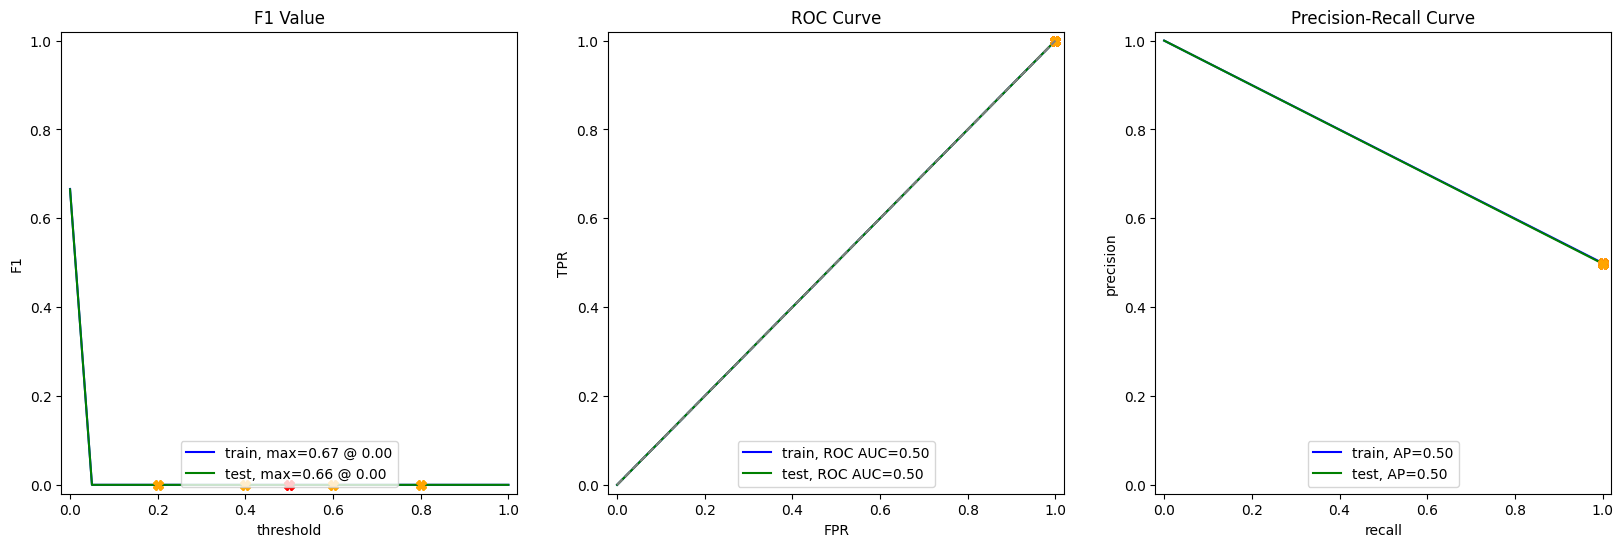

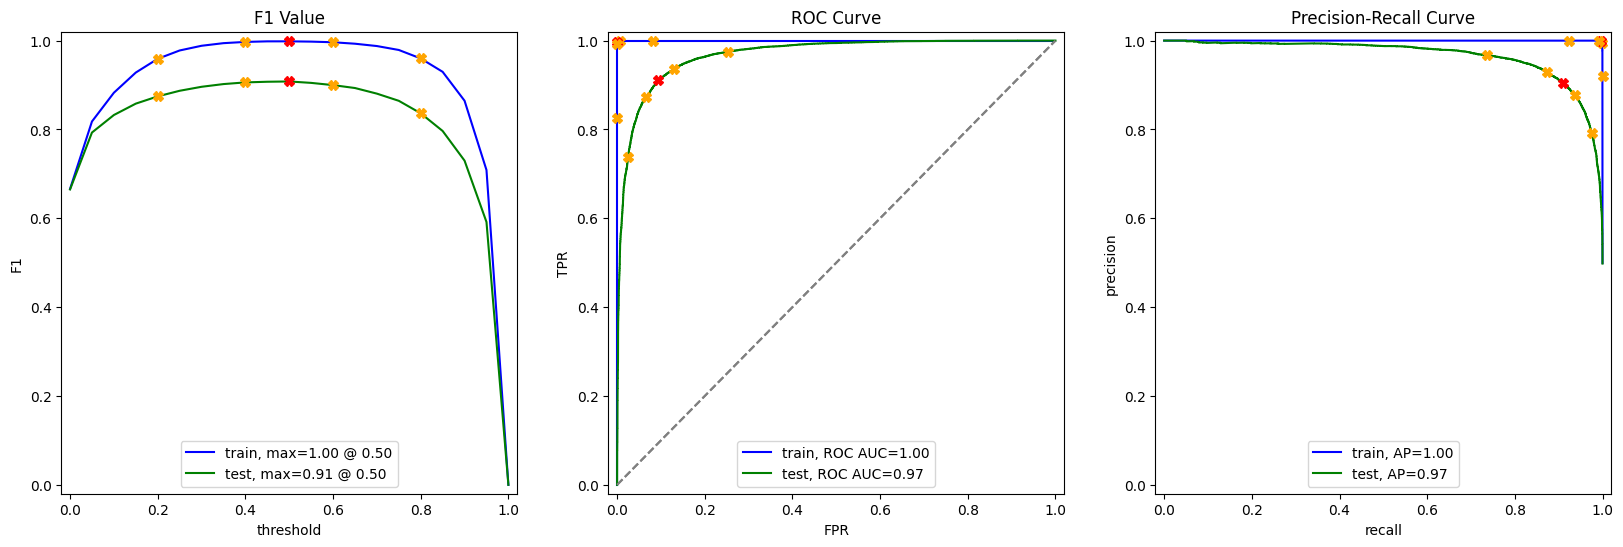

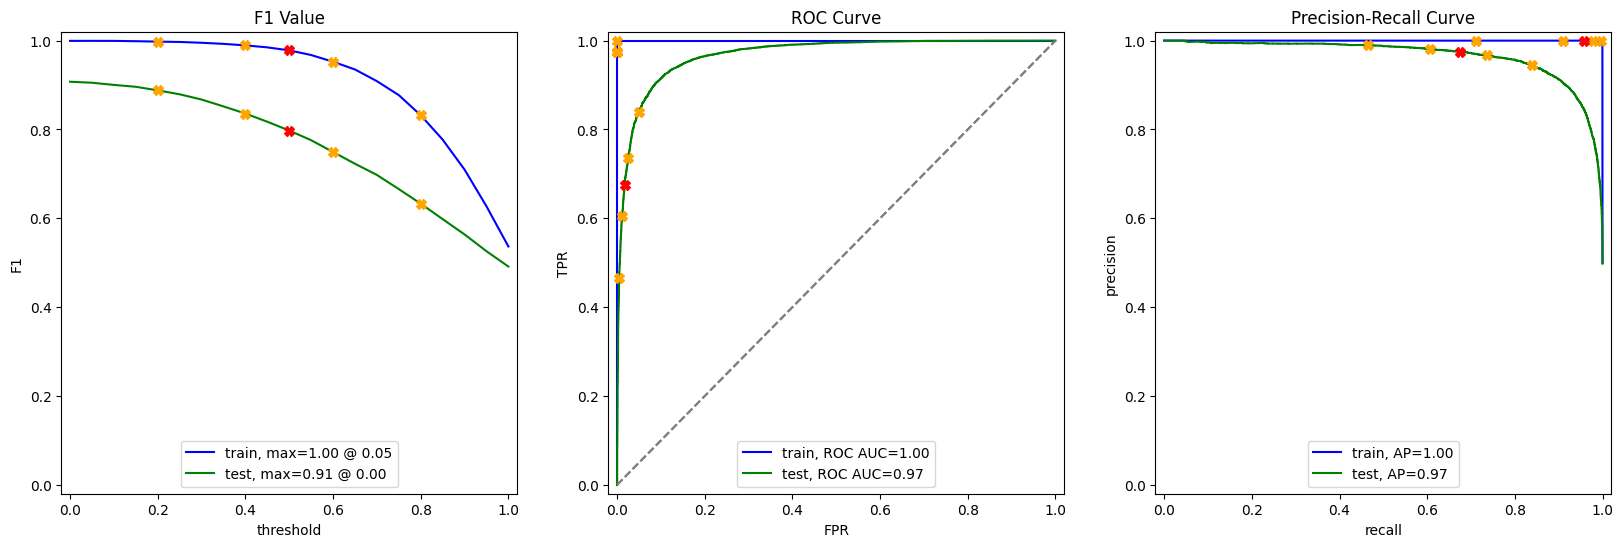

In [ ]:
# Model Evaluation on Cleaned Text and full data set (Unigrams and Bigrams, No Lemmatization)

models_v2 = [
    ("Dummy", DummyClassifier(strategy="most_frequent"), dummy_params),
    ("LogReg", LogisticRegression(max_iter=1000), logreg_params),
    ("SVM", LinearSVC(max_iter=5000), svm_params)
]

for name, model, params in models_v2:
    train_eval_with_search(
        model,
        params,
        X_extend_train_basic,
        X_extend_test_basic,
        y_train,
        y_test,
        model_name=name
)

Multinomial Naive Bayes was not used in the extended experiment, as this model assumes non-negative count-based features. The inclusion of scaled numeric variables, which can take negative values, violates that assumption. Additionally, MultinomialNB is specifically designed for bag-of-words representations, making discriminative models such as Logistic Regression more appropriate for combining text and structured variables.


===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== LogReg =====

Best LogReg F1 Score: 0.91 

Best params: {'solver': 'lbfgs', 'C': 10}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97

===== SVM =====

Best SVM F1 Score: 0.91 

Best params: {'C': 1}
          train  test
Accuracy    1.0  0.91
F1          1.0  0.91
APS         1.0  0.97
ROC AUC     1.0  0.97


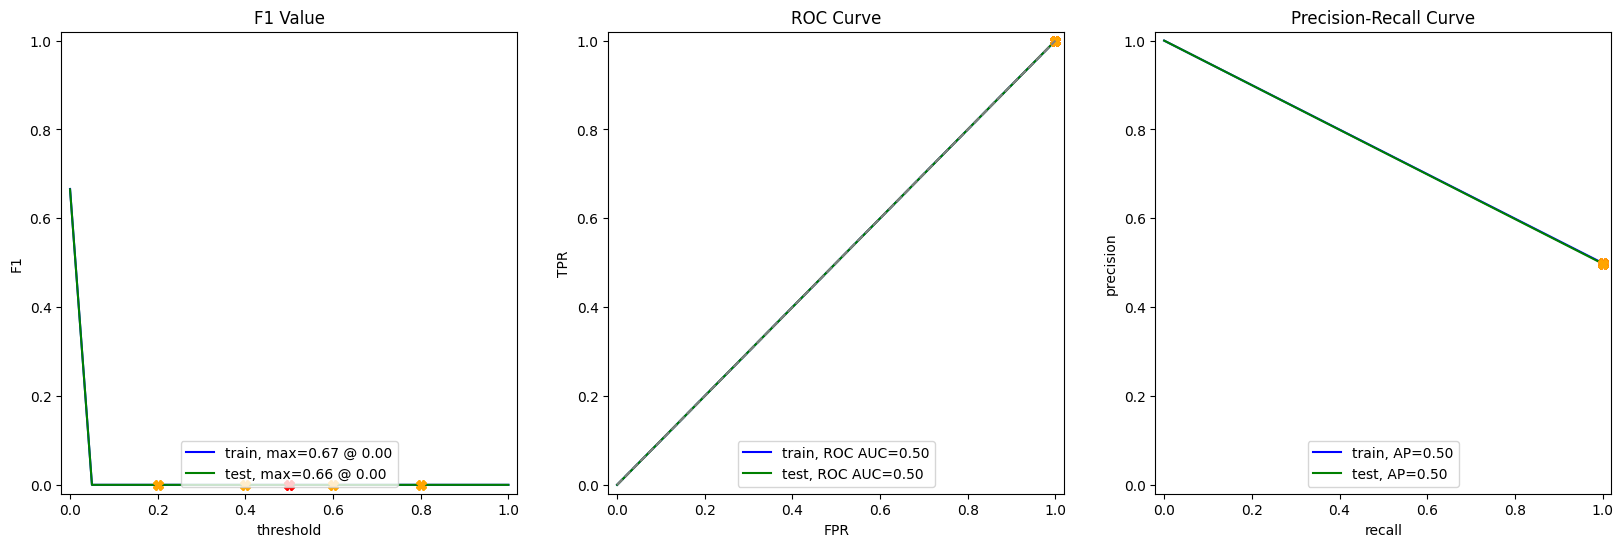

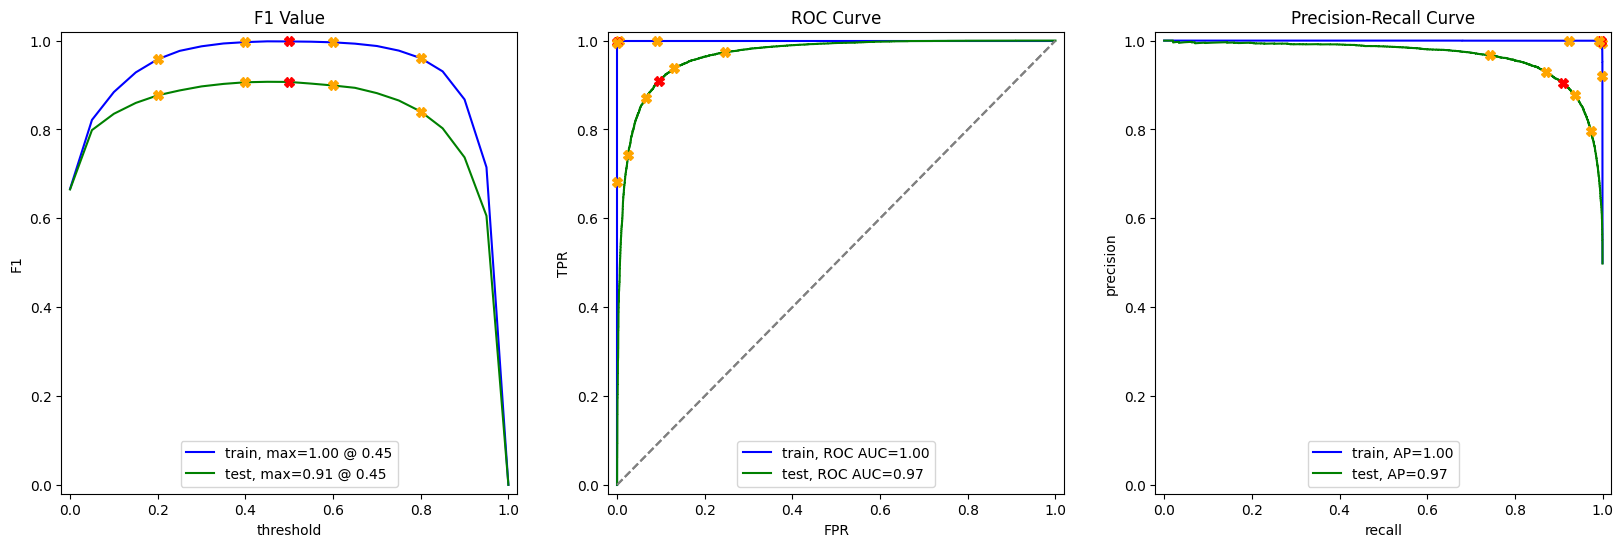

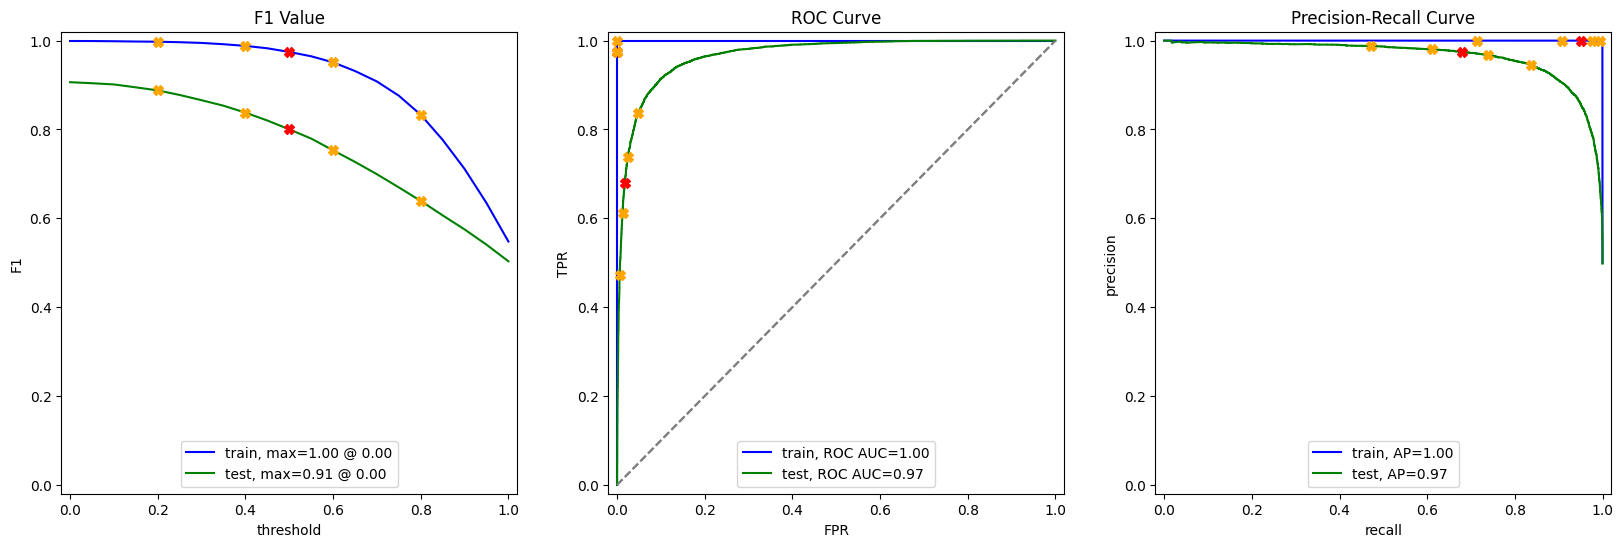

In [ ]:
# Model Evaluation on Lemmatized Text and full data set as well as unigrams and bigrams

for name, model, params in models_v2:
    train_eval_with_search(
        model,
        params,
        X_extend_train_lemm,
        X_extend_test_lemm,
        y_train,
        y_test,
        model_name=name
    )

### Contextual Embeddings (BERT) with Linear Classifiers and only text based


===== Dummy =====

Best Dummy F1 Score: 0.00 

Best params: {}
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5

===== LogReg =====

Best LogReg F1 Score: 0.88 

Best params: {'solver': 'lbfgs', 'C': 0.1}
          train  test
Accuracy   0.89  0.88
F1         0.89  0.88
APS        0.95  0.95
ROC AUC    0.95  0.95

===== SVM =====

Best SVM F1 Score: 0.88 

Best params: {'C': 0.01}
          train  test
Accuracy   0.89  0.88
F1         0.89  0.88
APS        0.95  0.95
ROC AUC    0.95  0.95


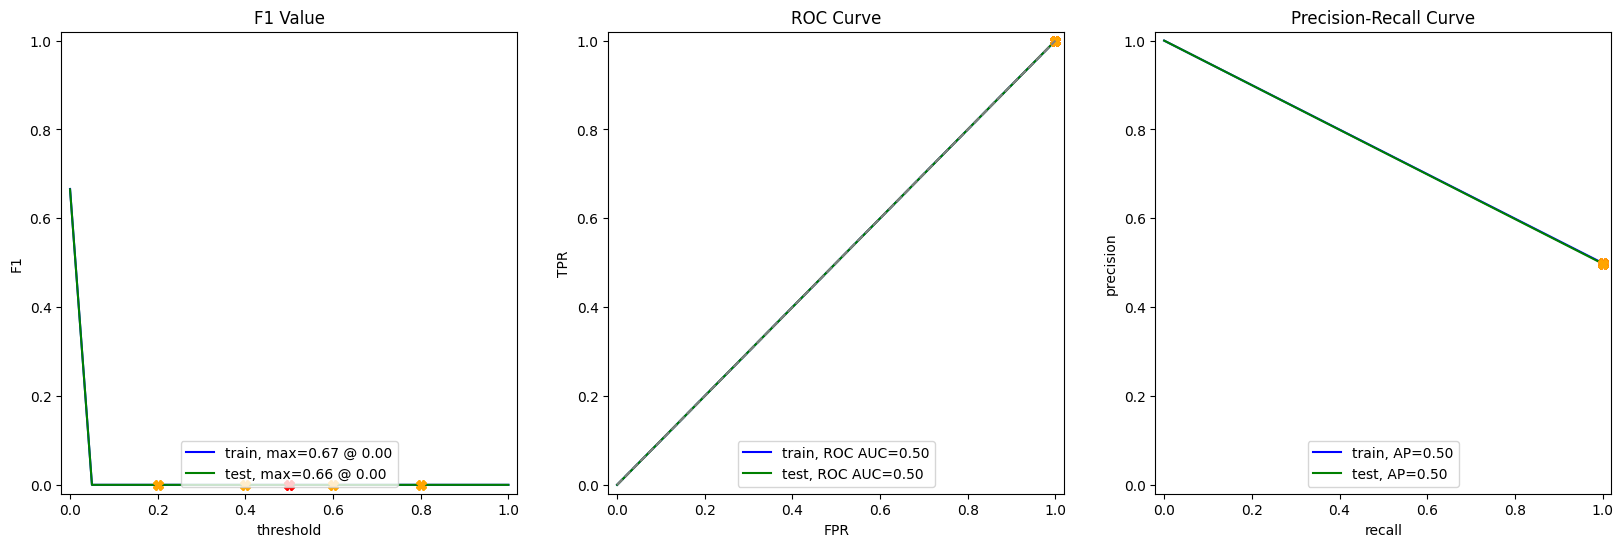

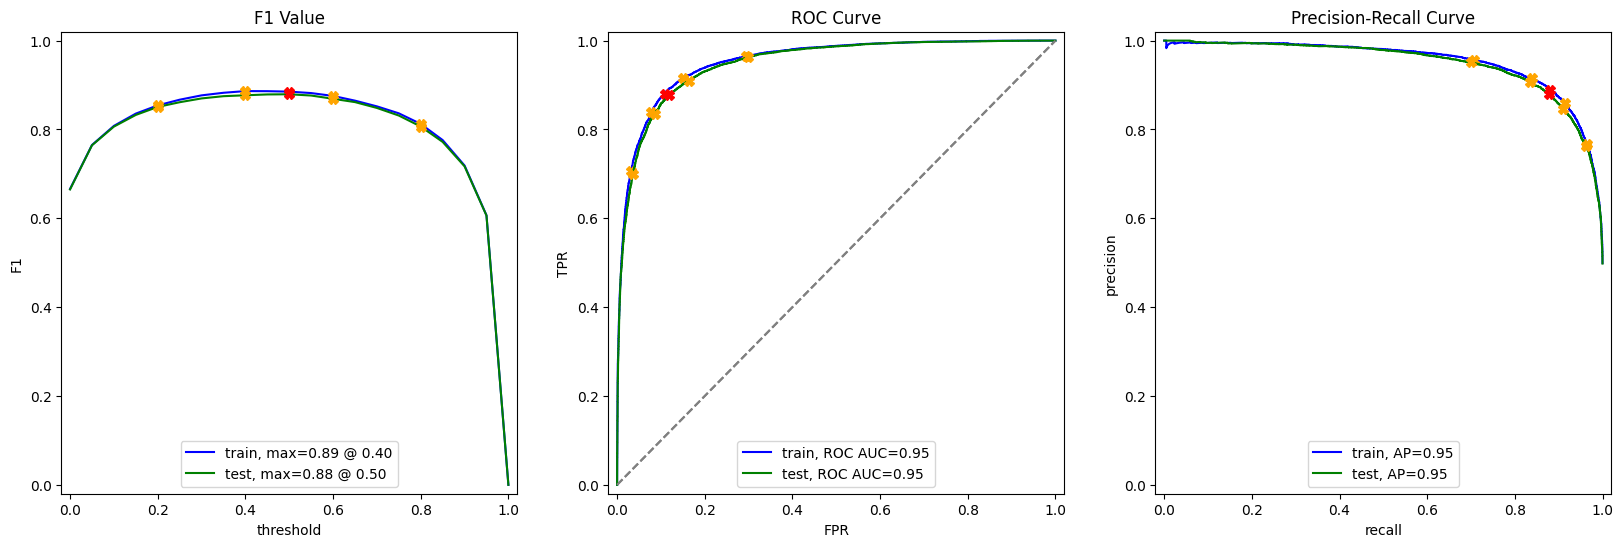

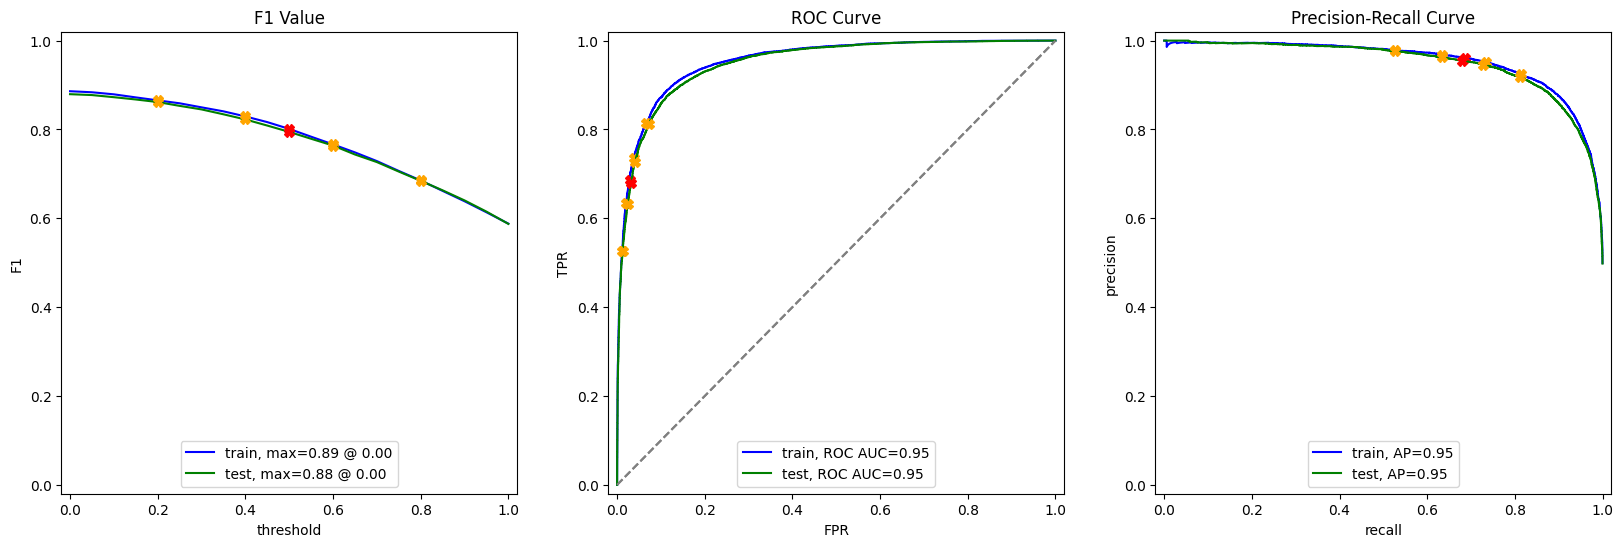

In [54]:
X_train_bert = train_embeddings
X_test_bert = test_embeddings


for name, model, params in models_v2:
    train_eval_with_search(
        model,
        params,
        X_train_bert,
        X_test_bert,
        y_train,
        y_test,
        model_name=name
)

While a feature-enriched version combining BERT embeddings with structured variables (genres and numeric features) was considered, it was not pursued. The extended TF-IDF experiment had already demonstrated that structured variables contribute only marginally over text alone, and in practice, sentiment classification systems rarely rely on features beyond the review text itself. Adding structured variables to BERT embeddings would have introduced unnecessary complexity without a meaningful expected gain.


## Conclusion

This project addressed binary sentiment classification from movie review text through a structured experimental framework encompassing controlled dataset partitioning, systematic preprocessing, feature engineering, hyperparameter optimization, and comprehensive performance evaluation.

The baseline model, built on TF-IDF representations using unigrams and bigrams, achieved strong performance (F1 = 0.90; ROC AUC = 0.96 on the test set). Lemmatization did not produce significant improvements, suggesting the original lexical representation was sufficient to capture the sentiment signal in the data.
An extended version incorporating structured variables (genres and scaled numeric features) yielded only marginal gains, confirming that textual content remains the primary source of predictive information.

BERT embeddings were also evaluated as a frozen feature extractor, meaning BERT's weights were not updated during training. Instead, CLS token embeddings were extracted and fed into the same linear classifiers. This approach achieved F1 = 0.88 and ROC AUC = 0.95, slightly below the TF-IDF baseline. Notably however, BERT showed no gap between train and test performance, indicating better generalization. The modest results are expected given that BERT was not fine-tuned on this task, a fine-tuned BERT would likely reach 93–95% F1, at significantly higher computational cost.

Among all models evaluated, Logistic Regression and Linear SVM consistently reached equivalent performance. Logistic Regression was selected as the final model due to its ability to produce calibrated probabilities, greater interpretability, and its well-established role as a strong baseline in text classification tasks.
Overall, the results demonstrate that classical linear models remain highly competitive in sentiment analysis when combined with rigorous experimental design and appropriate text representation. Future work could explore end-to-end fine-tuning of transformer architectures to evaluate potential gains over the established baseline.

For deployment, the baseline configuration — TF-IDF on non-lemmatized text without additional structured features — was selected despite not being the highest-scoring variant. The 0.01 F1 improvement from lemmatization or feature enrichment does not justify the added preprocessing overhead, and the baseline pipeline is lightweight enough for low-cost cloud deployment with no GPU dependency.
